In [3]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [5]:
import pandas as pd

# Load CodeAlpha Iris dataset
df = pd.read_csv("Iris.csv")

# Display first 5 rows
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [6]:
# Check dataset information

print("Shape of dataset:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

Shape of dataset: (150, 6)

Column names:
['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']

Missing values:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


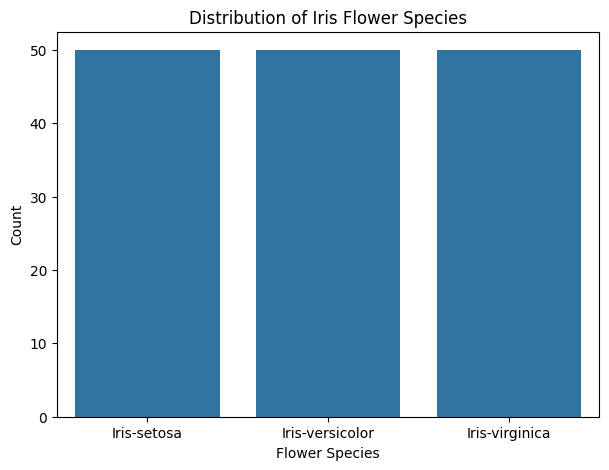

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize flower species distribution
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Species")
plt.title("Distribution of Iris Flower Species")
plt.xlabel("Flower Species")
plt.ylabel("Count")
plt.show()

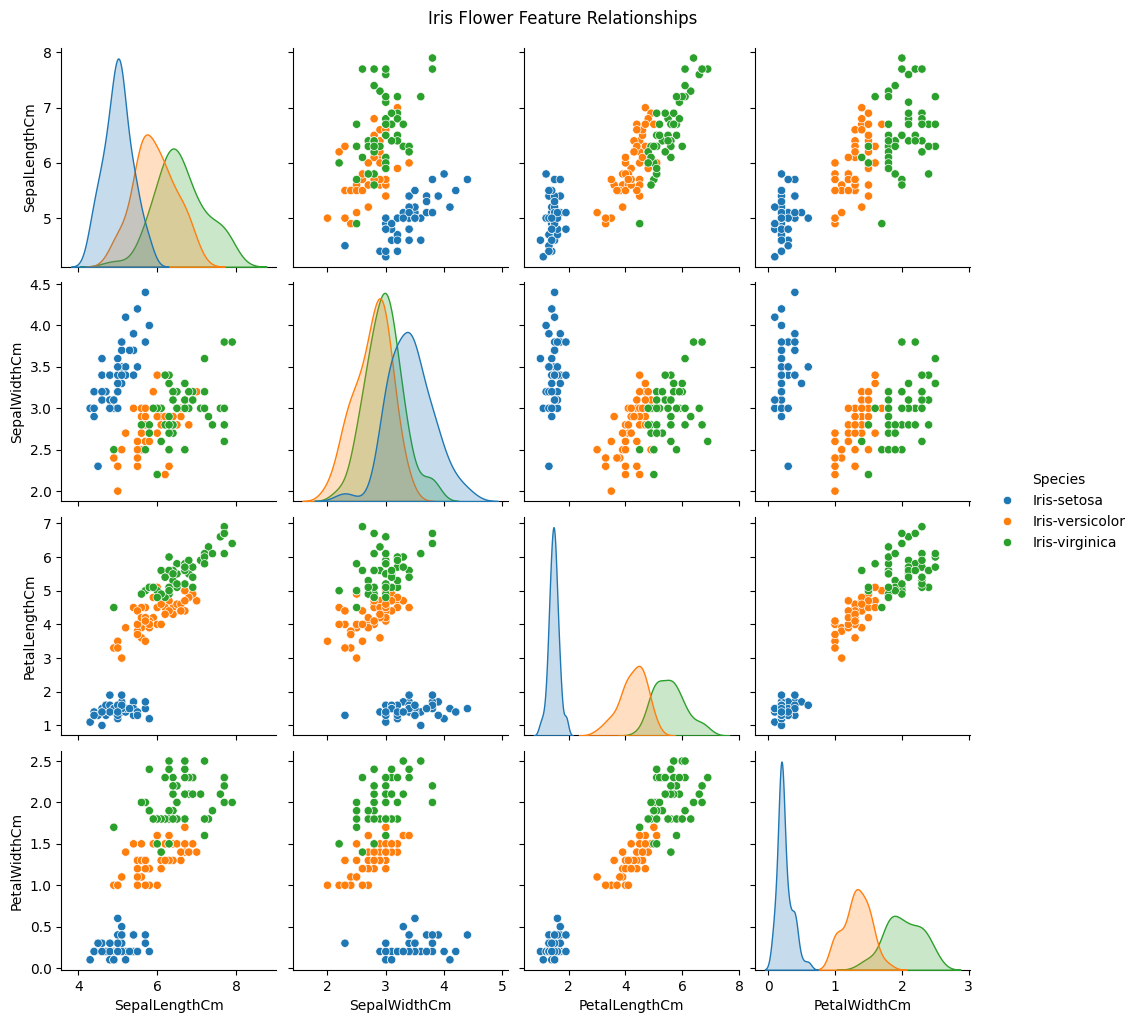

In [8]:
# Pairplot to visualize relationships between flower measurements

sns.pairplot(
    df,
    hue="Species",
    vars=["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]
)

plt.suptitle("Iris Flower Feature Relationships", y=1.02)
plt.show()

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression

# Select input features
X = df[["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]]

# Select target
y = df["Species"]

# Convert flower names into numbers
encoder = LabelEncoder()
y = encoder.fit_transform(y)

# Split dataset into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

# Create and train the model
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

print("Model training completed successfully!")

Training data: (120, 4)
Testing data: (30, 4)
Model training completed successfully!


In [10]:
from sklearn.metrics import accuracy_score, classification_report

# Make predictions on test data
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)
print("\nAccuracy Percentage:", round(accuracy * 100, 2), "%")

# Detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=encoder.classes_))

Model Accuracy: 0.9666666666666667

Accuracy Percentage: 96.67 %

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



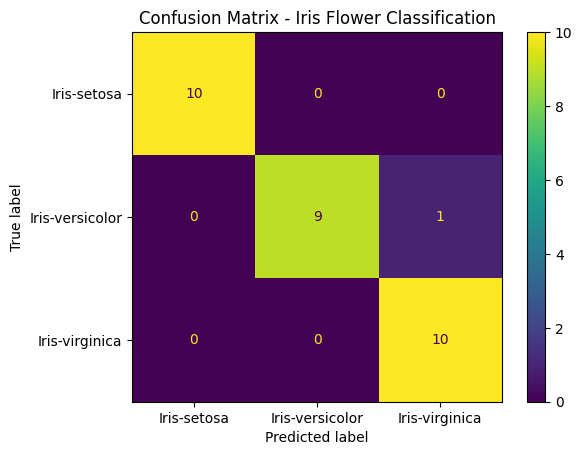

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=encoder.classes_
)

disp.plot()
plt.title("Confusion Matrix - Iris Flower Classification")
plt.show()

In [12]:
# Compare actual and predicted values

comparison = pd.DataFrame({
    "Actual": encoder.inverse_transform(y_test),
    "Predicted": encoder.inverse_transform(y_pred)
})

comparison.head(10)

,Actual,Predicted
0,Iris-setosa,Iris-setosa
1,Iris-virginica,Iris-virginica
2,Iris-versicolor,Iris-versicolor
3,Iris-versicolor,Iris-versicolor
4,Iris-setosa,Iris-setosa
5,Iris-versicolor,Iris-versicolor
6,Iris-setosa,Iris-setosa
7,Iris-setosa,Iris-setosa
8,Iris-virginica,Iris-virginica
9,Iris-versicolor,Iris-versicolor


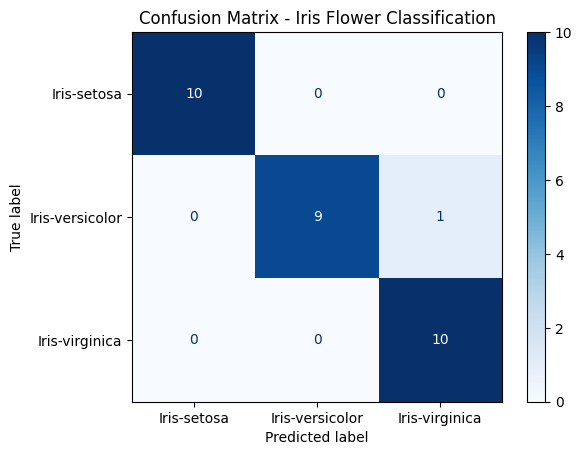

In [13]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=encoder.classes_
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Iris Flower Classification")
plt.show()

The Iris Flower Classification project successfully classified Iris flowers into three species: Iris-setosa, Iris-versicolor, and Iris-virginica. The dataset contained 150 records with no missing values. Logistic Regression was used for classification and achieved an accuracy of 96.67% on the test data. The confusion matrix and classification report show that the model performed very well in identifying the three flower species.

Project Result: 96.67% Accuracy